In [1]:
import sys

import polars as pl
import torch

import os


'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

save_dir = DIR + 'fit/20260106_running'


True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128


In [2]:
from modeling_module.models.PatchTST.supervised.PatchTST import PatchTSTPointModel
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from modeling_module.data_loader.MultiPartExoDataModule import MultiPartExoDataModule

# 사용자의 모듈 경로에 맞게 수정 필요
from modeling_module.models.PatchTST.common.configs import PatchTSTConfig

# -------------------------------------------------------------------------
# 1. 데이터 준비 및 임의의 외생변수 생성
# -------------------------------------------------------------------------
# (사용자가 제공한 전처리 로직)
target_dyn_demand_weekly = pl.read_parquet(DIR + 'target_dyn_demand_weekly.parquet').sort(['oper_part_no', 'demand_dt'])

# 필터링 로직 (길이 260 이상)
target_dyn_demand_weekly = (
    target_dyn_demand_weekly
    .group_by('oper_part_no', maintain_order=True)
    .map_groups(lambda g: g.with_columns(pl.arange(1, len(g) + 1).alias('seq')))
)
filtered_target = (
    target_dyn_demand_weekly
    .group_by('oper_part_no')
    .agg(pl.col('seq').max().alias('seq_max'))
    .filter(pl.col('seq_max') > 52)
    .select('oper_part_no')
)
df = target_dyn_demand_weekly.join(filtered_target, on='oper_part_no', how='inner')

# [NEW] 임의의 외생변수 추가
# 1) Past Continuous: 'price' (0~1 사이 랜덤 실수)
# 2) Past Categorical: 'event_id' (0~4 사이 랜덤 정수, cardinality=5)
np.random.seed(42)
n_rows = len(df)

df = df.with_columns([
    pl.Series(name="price", values=np.random.rand(n_rows)).cast(pl.Float64),
    pl.Series(name="event_id", values=np.random.randint(0, 5, n_rows)).cast(pl.Utf8) # DataModule이 str을 받아 인덱싱하도록 유도
])

print(f"Data Prepared. Shape: {df.shape}")
print(df.head(3))

# -------------------------------------------------------------------------
# 2. Future Exogenous Callback 정의
# -------------------------------------------------------------------------
# 미래 시점의 'promotion' (연속형) 정보를 반환한다고 가정
def dummy_future_exo_cb(start_idx: int, horizon: int, device: str):
    # 실제로는 start_idx(날짜 인덱스)를 기반으로 조회해야 하지만, 테스트용으로 랜덤 생성
    # [Horizon, d_future]
    return torch.randn(horizon, 1, device=device)
# def calendar_sin_cos(t: torch.Tensor, period: float, device: str) -> torch.Tensor:
#     """
#     단일 주기에 대한 sin/cos 쌍 반환 (..., 2)
#     """
#     return torch.stack([
#         torch.sin(2 * torch.pi * t / period),
#         torch.cos(2 * torch.pi * t / period)
#     ], dim=-1)


Data Prepared. Shape: (1095148, 6)
shape: (3, 6)
┌──────────────┬───────────┬────────────┬─────┬──────────┬──────────┐
│ oper_part_no ┆ demand_dt ┆ demand_qty ┆ seq ┆ price    ┆ event_id │
│ ---          ┆ ---       ┆ ---        ┆ --- ┆ ---      ┆ ---      │
│ str          ┆ i64       ┆ f64        ┆ i64 ┆ f64      ┆ str      │
╞══════════════╪═══════════╪════════════╪═════╪══════════╪══════════╡
│ 01023-50612  ┆ 201802    ┆ 10.0       ┆ 1   ┆ 0.37454  ┆ 2        │
│ 01023-50612  ┆ 201817    ┆ 2.0        ┆ 2   ┆ 0.950714 ┆ 0        │
│ 01023-50612  ┆ 201821    ┆ 20.0       ┆ 3   ┆ 0.731994 ┆ 1        │
└──────────────┴───────────┴────────────┴─────┴──────────┴──────────┘


In [3]:


# -------------------------------------------------------------------------
# 3. 설정 (Config) 및 DataModule 초기화
# -------------------------------------------------------------------------
lookback = 24
horizon = 8
patch_len = 8
stride = 4
actual_cardinality = 5 + 1  # 0(UNK) + 1,2,3,4,5

# DataModule 설정
dm = MultiPartExoDataModule(
    df=df,
    lookback=lookback,
    horizon=horizon,
    freq='weekly',
    batch_size=512,
    part_col='oper_part_no',
    date_col='demand_dt',
    qty_col='demand_qty',

    # 외생변수 컬럼 지정
    past_exo_cont_cols=['price'],
    past_exo_cat_cols=['event_id_id'], # build_cat_indexer_from 사용 시 _id 접미사 자동 생성 주의

    # Future Exo Callback
    future_exo_cb=dummy_future_exo_cb,

    # Categorical Indexing (문자열 -> 정수 변환)
    build_cat_indexer_from=['event_id'],
    cat_indexer_target_col='event_id_id' # 변환된 컬럼명 명시
)

dm.setup()
train_loader = dm.get_train_loader()
val_loader = dm.get_val_loader()



In [4]:
for train in train_loader:
    print(train)
    break

[tensor([[[  3.],
         [  1.],
         [  2.],
         ...,
         [ 33.],
         [ 15.],
         [ 10.]],

        [[  1.],
         [  8.],
         [  1.],
         ...,
         [  3.],
         [ 13.],
         [  6.]],

        [[  6.],
         [  5.],
         [  5.],
         ...,
         [  5.],
         [  1.],
         [  5.]],

        ...,

        [[  5.],
         [  5.],
         [  5.],
         ...,
         [  2.],
         [ 10.],
         [  1.]],

        [[  3.],
         [  3.],
         [  9.],
         ...,
         [  2.],
         [  4.],
         [  7.]],

        [[  5.],
         [203.],
         [105.],
         ...,
         [142.],
         [ 50.],
         [ 25.]]]), tensor([[  6.,   5.,  10.,  ...,   7.,  30.,   5.],
        [ 10.,   8.,   1.,  ...,  29.,  14.,   4.],
        [  2.,   2.,   5.,  ...,   5.,   2.,   1.],
        ...,
        [  1.,   1.,   1.,  ...,  10.,   2.,   2.],
        [  4.,   2.,   1.,  ...,   2.,  13.,   1.],
   

In [5]:
ds = train_loader.dataset
if hasattr(ds, 'dataset'): ds = ds.dataset # Subset핑

print("=== Debugging Cardinalities ===")
if hasattr(ds, 'cat_indexers'):
    for col, indexer in ds.cat_indexers.items():
        max_id_in_map = max(indexer.mapping.values())
        print(f"Column '{col}': Max ID in Data = {max_id_in_map}, Required Cardinality >= {max_id_in_map + 1}")

        # total_train.py의 로직이 이걸 잘 잡는지 확인
        calculated_card = max_id_in_map + 1
        print(f" -> Config will use: {calculated_card}")

=== Debugging Cardinalities ===
Column 'event_id': Max ID in Data = 5, Required Cardinality >= 6
 -> Config will use: 6


In [6]:
from modeling_module.training.model_trainers.total_train import run_total_train_weekly

model_dict = run_total_train_weekly(
    train_loader,
    val_loader,
    lookback=lookback, horizon=horizon, save_dir=save_dir,
    models_to_run=['patchtst']
)


[total_train] === RUN: patchtst (weekly) ===
exogenous dimension:: 2
PatchTST Base (Weekly)
[train_patchtst] head rebuilt: d_future 2 -> 1
[train_patchtst] loader provides fe_cont(E=1), so future_exo_cb disabled.

[train_patchtst] ===== Stage 1/2 =====
  - spike: OFF
  - epochs: 1 | lr=0.0003 | horizon_decay=False
[train_patchtst] Effective TrainingConfig:
{
  "device": "cuda",
  "lookback": 24,
  "horizon": 8,
  "epochs": 1,
  "lr": 0.0003,
  "weight_decay": 0.001,
  "t_max": 40,
  "patience": 100,
  "max_grad_norm": 30.0,
  "amp_device": "cuda",
  "loss_mode": "point",
  "point_loss": "huber",
  "huber_delta": 0.8,
  "q_star": 0.5,
  "use_cost_q_star": false,
  "Cu": 1.0,
  "Co": 1.0,
  "quantiles": [
    0.1,
    0.5,
    0.9
  ],
  "use_intermittent": true,
  "alpha_zero": 3.0,
  "alpha_pos": 1.0,
  "gamma_run": 0.3,
  "cap": null,
  "use_horizon_decay": false,
  "tau_h": 0.85,
  "val_use_weights": false,
  "spike_loss": {
    "enabled": false,
    "strategy": "mix",
    "huber_de

In [7]:
from modeling_module.utils.checkpoint import load_model_dict
from modeling_module.models.model_builder import build_patchTST_base, build_patchTST_quantile

builders = {
    'patchtst_base': build_patchTST_base,
    'patchtst_quantile': build_patchTST_quantile
}
device = 'cuda'
loaded = load_model_dict(save_dir, builders, device = device)

[load] patchtst_base ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20260106_running\patchtst_base.pt
{'device': 'cuda', 'lookback': 52, 'horizon': 8, 'epochs': 1, 'lr': 0.0001, 'weight_decay': 0.0001, 't_max': 10, 'patience': 50, 'max_grad_norm': 30.0, 'amp_device': 'cuda', 'loss_mode': 'point', 'point_loss': 'huber', 'huber_delta': 5.0, 'q_star': 0.5, 'use_cost_q_star': False, 'Cu': 1.0, 'Co': 1.0, 'quantiles': (0.1, 0.5, 0.9), 'use_intermittent': True, 'alpha_zero': 1.2, 'alpha_pos': 1.0, 'gamma_run': 0.6, 'cap': None, 'use_horizon_decay': False, 'tau_h': 24.0, 'val_use_weights': False, 'spike_loss': {'enabled': True, 'strategy': 'mix', 'huber_delta': 2.0, 'asym_up_weight': 2.0, 'asym_down_weight': 1.0, 'mad_k': 3.5, 'w_spike': 6.0, 'w_norm': 1.0, 'alpha_huber': 0.7, 'beta_asym': 0.3, 'mix_with_baseline': False, 'gamma_baseline': 0.2}, 'lambda_hist_scale': 0.1, 'lambda_hist_var': 0.03, 'hist_window': 12, 'anchor_last_k': 8, 'anchor_weight': 0.05, 'c_in': 1, 'target_dim': 1, '

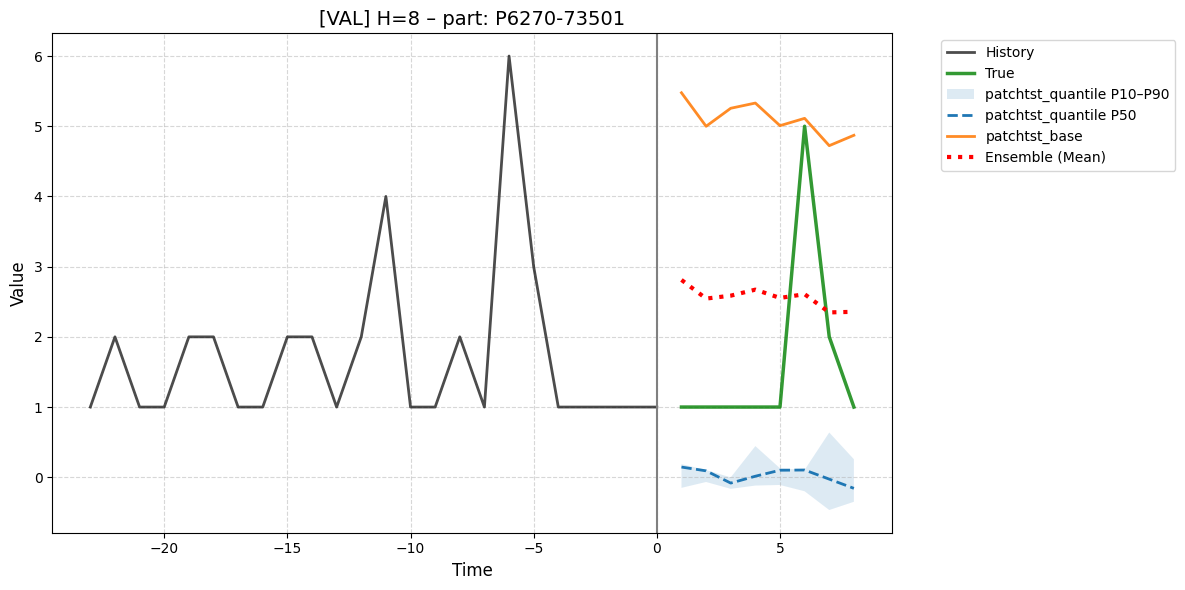

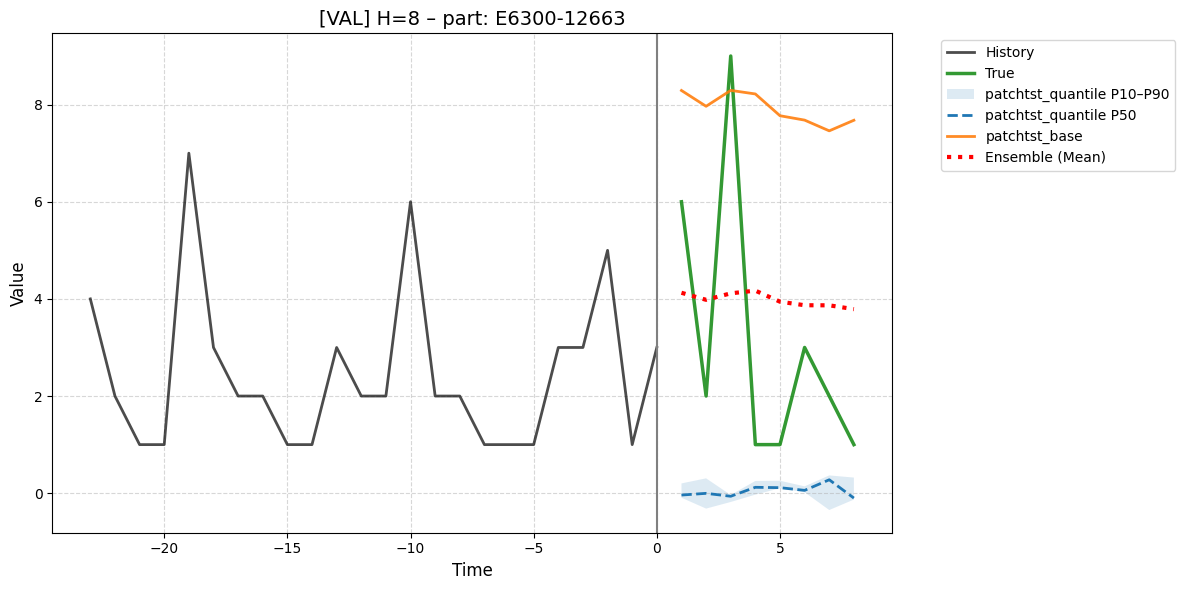

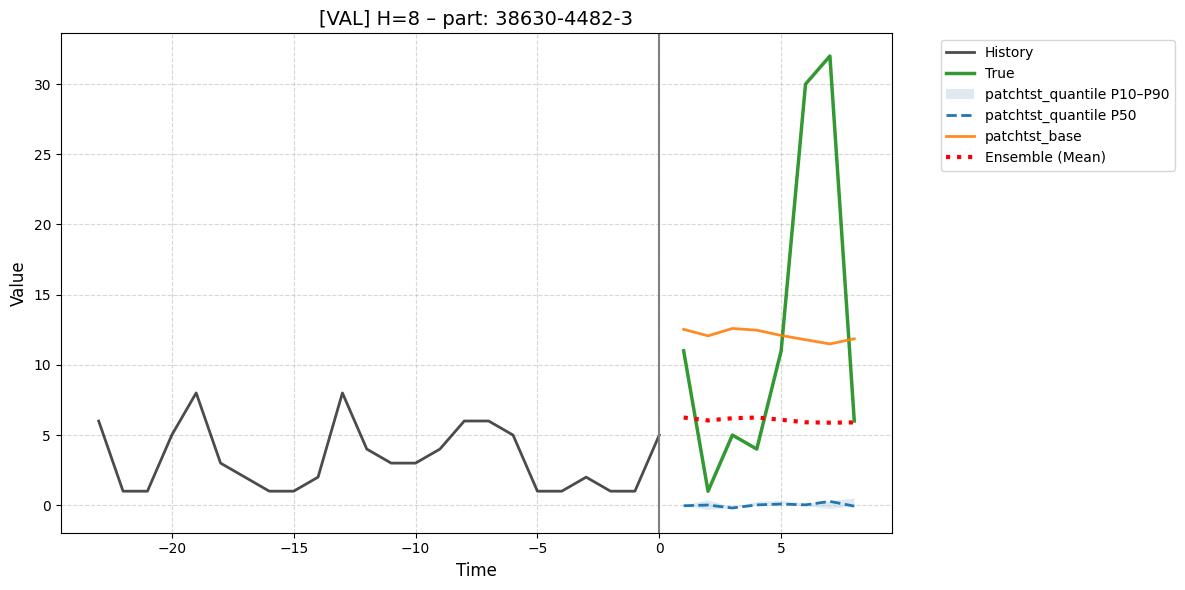

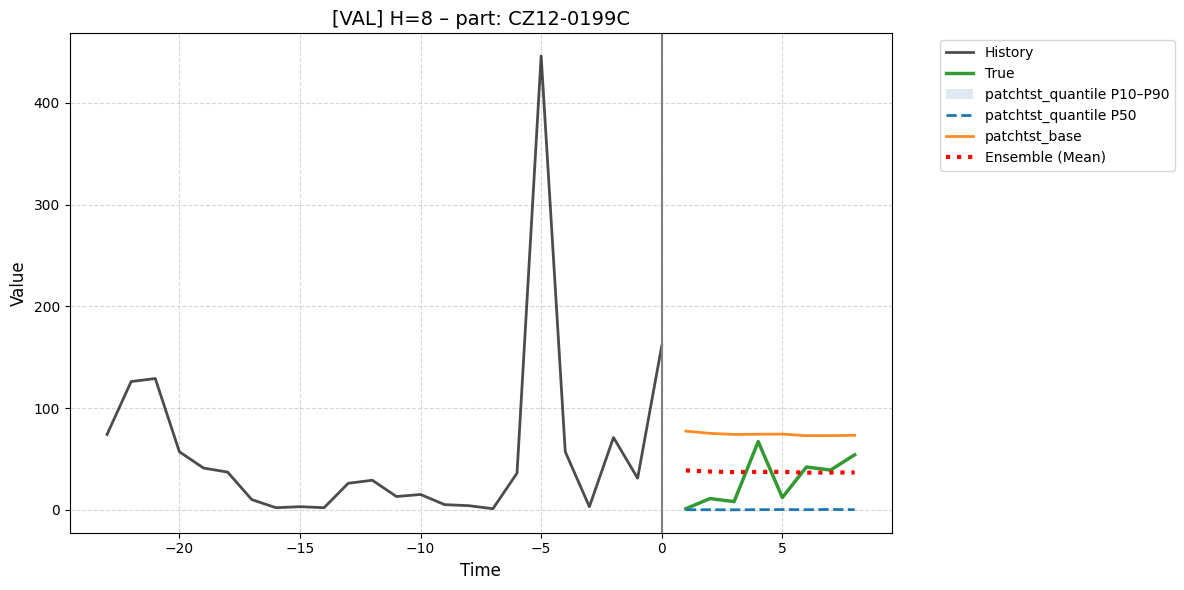

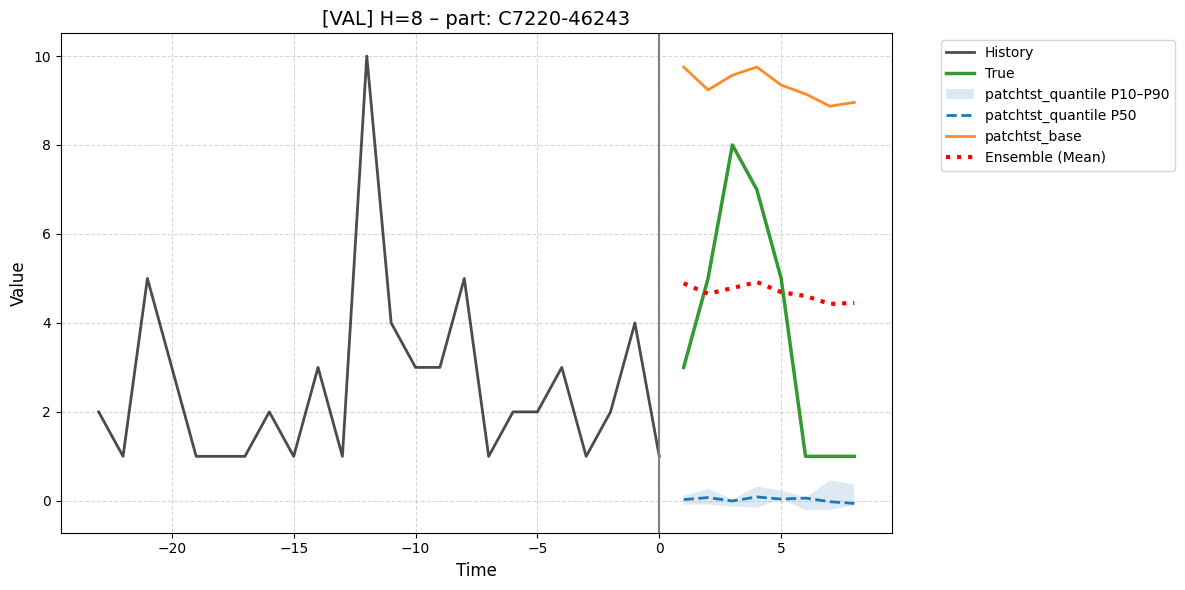

In [8]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda" if torch.cuda.is_available() else "cpu"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=52, device=device)

pu.plot_27w(
    models=loaded,           # {"PatchMixer": pm_model, "Titan": ti_model, ...}
    loader=val_loader,       # (xb, yb[, part_ids])
    device="cuda" if torch.cuda.is_available() else "cpu",
    mode="val",              # ← 검증 모드
    max_plots=5,
    out_dir=None,
    show=True,
    future_exo_cb=None
)